# DATA 266 Lab 1 - Task 3: CycleGAN

**Student: Yuyao Ding**

Domain A is Monet and domain B is photographs. Two generators learn A→B and
B→A; two PatchGAN discriminators judge the corresponding target domains.
All four networks start from random weights. Pretrained networks are used
only to measure validation and test results.

Restart the kernel and run the cells in order for the formal configuration
in `configs/training.json`. Set `RUN_FORMAL_TRAINING = False` for a smoke run.
The earlier six-block run and its executed notebook are preserved in
`outputs/task3_formal_20260927T043055Z_42bb4f28/`.
The model definitions are in `cyclegan.py`; `evaluate.py` and `demo.py` also use
these definitions when loading a checkpoint. See the member README for setup.

## 1. Setup

Keep `USE_COLAB_DRIVE` false on Windows, Mac and Linux. On Colab, mount Drive
and set `PROJECT_ROOT` to the complete project folder. `RESUME_CHECKPOINT`
accepts a `last.pt` path relative to that folder or an absolute path.
Resume restores the last complete epoch and writes a new run directory.

In [1]:
USE_COLAB_DRIVE = False
RUN_FORMAL_TRAINING = True
PROJECT_ROOT = None
RESUME_CHECKPOINT = None
DEVICE = None
RUN_EVALUATION = True
STOP_AFTER_EPOCH = None  # Set an epoch number for a planned pause.

In [2]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import copy
import csv
import hashlib
import importlib
import itertools
import json
import math
import platform
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict
from contextlib import nullcontext
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import psutil
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from tqdm.auto import tqdm

if USE_COLAB_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    if PROJECT_ROOT is None:
        raise ValueError("Set PROJECT_ROOT to the complete project folder on Drive.")

if PROJECT_ROOT is None:
    PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                         if (p / "task3_gan/Yuyao_Ding/src").is_dir()), None)
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Start Jupyter inside the project or set PROJECT_ROOT.")
PROJECT_ROOT = Path(PROJECT_ROOT).expanduser().resolve()
MEMBER = PROJECT_ROOT / "task3_gan/Yuyao_Ding"
SOURCE = MEMBER / "src"
sys.path.insert(0, str(SOURCE))
import cyclegan
import evaluate
importlib.reload(cyclegan)
importlib.reload(evaluate)
from cyclegan import (make_models, read_checkpoint, save_checkpoint, save_image,
                     select_device, sha256, synchronize, image_tensor, tensor_image,
                     translate_files, write_json)
from evaluate import InceptionFeatures, kernel_distance, evaluate_checkpoint

config = json.loads((MEMBER / "configs/training.json").read_text(encoding="utf-8"))
if not RUN_FORMAL_TRAINING:
    config.update(image_size=64, resize_size=72, width=8, residual_blocks=1,
                  discriminator_width=8, epochs=2, steps_per_epoch=2,
                  decay_start_epoch=1, checkpoint_every=2, batch_size=1, pool_size=4,
                  validation_images_per_domain=8, evaluation_batch_size=8,
                  kid_subsets=3, kid_subset_size=8, audit_samples_per_direction=3)
if DEVICE is not None:
    config["device"] = DEVICE
device = select_device(config["device"])
metric_device = torch.device("cpu") if device.type == "mps" else device
torch.hub.set_dir(str(PROJECT_ROOT / "task3_gan/data/metric_weights"))
torch.set_num_threads(min(8, os.cpu_count() or 1))
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.use_deterministic_algorithms(True, warn_only=True)
use_amp = bool(config["cuda_bfloat16"] and device.type == "cuda" and torch.cuda.is_bf16_supported())

for key in ("width", "residual_blocks", "discriminator_width", "epochs", "batch_size",
            "pool_size", "validation_images_per_domain", "checkpoint_every"):
    if not isinstance(config[key], int) or config[key] < 1:
        raise ValueError(f"{key} must be a positive integer.")
step_limit = config["steps_per_epoch"]
if step_limit is not None and (not isinstance(step_limit, int) or step_limit < 1):
    raise ValueError("steps_per_epoch must be null or a positive integer.")
if not 0 < config["decay_start_epoch"] < config["epochs"]:
    raise ValueError("Learning-rate decay must start before the final epoch.")
if config["image_size"] % 4 or config["resize_size"] < config["image_size"]:
    raise ValueError("Use an image size divisible by 4 and a resize size at least as large.")
if config["learning_rate"] <= 0 or min(config["lambda_cycle"], config["lambda_identity"]) < 0:
    raise ValueError("Invalid learning rate or loss weights.")
print("Mode:", "formal" if RUN_FORMAL_TRAINING else "smoke")
print("Training device:", device, "| metric device:", metric_device, "| CUDA bfloat16:", use_amp)
print(json.dumps(config, indent=2))

Mode: formal
Training device: cuda | metric device: cuda | CUDA bfloat16: False
{
  "seed": 41,
  "device": "auto",
  "image_size": 256,
  "resize_size": 286,
  "width": 64,
  "residual_blocks": 9,
  "upsampling": "transpose",
  "discriminator_width": 64,
  "batch_size": 1,
  "epochs": 100,
  "steps_per_epoch": 1000,
  "decay_start_epoch": 50,
  "checkpoint_every": 5,
  "learning_rate": 0.0002,
  "beta1": 0.5,
  "beta2": 0.999,
  "lambda_cycle": 10.0,
  "lambda_identity": 5.0,
  "pool_size": 50,
  "cuda_bfloat16": false,
  "validation_fraction": 0.1,
  "test_fraction": 0.1,
  "validation_images_per_domain": 30,
  "evaluation_batch_size": 16,
  "kid_subsets": 50,
  "kid_subset_size": 100,
  "nearest_k": 5,
  "audit_samples_per_direction": 15
}


## 2. Raw data, duplicate groups and fixed splits

The downloaded raw files are never removed or renamed. File hashes are checked
against the saved inventory. We split by image-file hash, so identical copies
stay together. Approximately 80% of each domain is for training, 10% for
validation, and 10% for the final test. Sampling is unpaired.

The same seed fixes the test subset and 30 audit cases (15 in each direction)
before training. A smoke run uses smaller subsets and six audit cases only.
Kaggle's train-inclusive reference protocol is reported separately from the
held-out test; it is never used to select a checkpoint.

In [3]:
inventory_path = PROJECT_ROOT / "reproducibility/manifests/Yuyao_Ding/task3_data_inventory.json"
inventory = json.loads(inventory_path.read_text(encoding="utf-8"))
image_hashes = {row["path"]: row["sha256"] for row in inventory["images"]}
for path, expected_hash in image_hashes.items():
    if sha256(PROJECT_ROOT / path) != expected_hash:
        raise ValueError(f"Raw image changed or is missing: {path}")

def make_split():
    split = {name: {} for name in ("train", "validation", "test")}
    split["seed"] = config["seed"]
    split["validation_fraction"] = config["validation_fraction"]
    split["test_fraction"] = config["test_fraction"]
    split["data_inventory_sha256"] = sha256(inventory_path)
    for index, (domain, folder) in enumerate((("A", "monet_jpg"), ("B", "photo_jpg"))):
        groups = defaultdict(list)
        for path, digest in image_hashes.items():
            if Path(path).parent.name == folder:
                groups[digest].append(path)
        keys = sorted(groups)
        random.Random(config["seed"] + index).shuffle(keys)
        n_val = max(1, round(len(keys) * config["validation_fraction"]))
        n_test = max(1, round(len(keys) * config["test_fraction"]))
        if n_val + n_test >= len(keys):
            raise ValueError("Validation and test fractions leave no training images.")
        assigned = {"validation": keys[:n_val], "test": keys[n_val:n_val + n_test],
                    "train": keys[n_val + n_test:]}
        for name, hashes in assigned.items():
            split[name][domain] = sorted(path for digest in hashes for path in groups[digest])
    for first, second in (("train", "validation"), ("train", "test"), ("validation", "test")):
        left = {image_hashes[p] for domain in ("A", "B") for p in split[first][domain]}
        right = {image_hashes[p] for domain in ("A", "B") for p in split[second][domain]}
        assert not left & right, "Identical images crossed data splits."
    return split

split = make_split()
split_path = MEMBER / "data_processed" / f"split_seed{config['seed']}.json"
if split_path.exists():
    if json.loads(split_path.read_text(encoding="utf-8")) != split:
        raise ValueError("The saved split differs. Use a new seed for a separate experiment.")
else:
    write_json(split_path, split)
split = copy.deepcopy(split)
if not RUN_FORMAL_TRAINING:
    for partition in ("train", "validation", "test"):
        for domain in ("A", "B"):
            split[partition][domain] = split[partition][domain][:16 if partition == "train" else 8]

test_count = min(len(split["test"]["A"]), len(split["test"]["B"]), 300)
audit_samples = []
for direction, domain in (("A2B", "A"), ("B2A", "B")):
    candidates = split["test"][domain][:test_count]
    chosen = random.Random(config["seed"] + 100).sample(candidates, config["audit_samples_per_direction"])
    audit_samples += [{"path": path, "direction": direction} for path in chosen]
random.Random(config["seed"] + 101).shuffle(audit_samples)
split["audit_samples"] = audit_samples
split_digest = hashlib.sha256(json.dumps(split, sort_keys=True).encode()).hexdigest()
print({name: {domain: len(split[name][domain]) for domain in ("A", "B")}
       for name in ("train", "validation", "test")})
print("Fixed audit cases:", len(audit_samples))

{'train': {'A': 240, 'B': 5631}, 'validation': {'A': 30, 'B': 703}, 'test': {'A': 30, 'B': 704}}
Fixed audit cases: 30


In [4]:
class UnpairedImages(Dataset):
    def __init__(self, paths_a, paths_b):
        self.paths_a, self.paths_b = paths_a, paths_b
        self.transform = T.Compose([
            T.Resize((config["resize_size"], config["resize_size"]), interpolation=T.InterpolationMode.BICUBIC),
            T.RandomCrop(config["image_size"]), T.RandomHorizontalFlip(),
            T.ToTensor(), T.Normalize((0.5,) * 3, (0.5,) * 3),
        ])

    def __len__(self):
        return max(len(self.paths_a), len(self.paths_b))

    def __getitem__(self, index):
        path_a = self.paths_a[index % len(self.paths_a)]
        path_b = random.choice(self.paths_b)
        with Image.open(PROJECT_ROOT / path_a) as image:
            a = self.transform(image.convert("RGB"))
        with Image.open(PROJECT_ROOT / path_b) as image:
            b = self.transform(image.convert("RGB"))
        return a, b, path_a, path_b

train_data = UnpairedImages(split["train"]["A"], split["train"]["B"])
actual_steps = math.ceil(len(train_data) / config["batch_size"])
if step_limit is not None:
    actual_steps = min(step_limit, actual_steps)
print("Optimizer updates per epoch:", actual_steps)
print("Full dataset epoch" if step_limit is None else "Limited updates per epoch")
print("Domain B is sampled with replacement; an epoch need not include every photo.")

Optimizer updates per epoch: 1000
Limited updates per epoch
Domain B is sampled with replacement; an epoch need not include every photo.


## 3. Networks and objective

The formal model uses nine residual blocks, 64 base channels and transpose-convolution
upsampling, matching the authors' default 256-pixel generator. Each discriminator produces a grid of real/fake scores without a sigmoid.
Instance normalization uses no running statistics. `cyclegan.py` contains the model
layers so the notebook, evaluator and demo cannot silently use different architectures.

The generator objective adds both least-squares adversarial losses, both cycle L1
losses weighted by 10, and both identity L1 losses weighted by 5. Identity feeds a
generator an image already in its target domain. Each discriminator averages its
real and detached-fake losses. A 50-image replay pool reduces abrupt discriminator
changes. Loss weights apply to tensors in [-1, 1].

References: [Zhu et al., CycleGAN (2017)](https://junyanz.github.io/CycleGAN/)
and the [authors' PyTorch implementation](https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix).
Architecture and hyperparameters must be compared with the teammate's design
before submission; their Task 3 model is not available in this project yet.

In [5]:
def seed_everything(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

class ImagePool:
    def __init__(self, capacity):
        self.capacity = capacity
        self.images = []

    def query(self, images):
        result = []
        for image in images.detach():
            image = image.unsqueeze(0)
            if len(self.images) < self.capacity:
                self.images.append(image.cpu().clone())
                result.append(image)
            elif random.random() > 0.5:
                index = random.randrange(self.capacity)
                previous = self.images[index].to(device=image.device, dtype=image.dtype).clone()
                self.images[index] = image.cpu().clone()
                result.append(previous)
            else:
                result.append(image)
        return torch.cat(result)

def set_discriminator_grad(models, enabled):
    for name in ("D_A", "D_B"):
        models[name].requires_grad_(enabled)

def grad_norm(model):
    return float(torch.nn.utils.clip_grad_norm_(
        model.parameters(), float("inf"), error_if_nonfinite=True).cpu())

def amp_context():
    return torch.autocast("cuda", dtype=torch.bfloat16) if use_amp else nullcontext()

def train_step(models, optimizer_g, optimizer_d, pool_a, pool_b, a, b):
    set_discriminator_grad(models, False)
    optimizer_g.zero_grad(set_to_none=True)
    with amp_context():
        fake_b = models["G_A2B"](a)
        fake_a = models["G_B2A"](b)
        cycle_a = models["G_B2A"](fake_b)
        cycle_b = models["G_A2B"](fake_a)
        identity_a = models["G_B2A"](a)
        identity_b = models["G_A2B"](b)
        pred_b, pred_a = models["D_B"](fake_b).float(), models["D_A"](fake_a).float()
        losses = {
            "G_A2B_adversarial": (pred_b - 1).square().mean(),
            "G_B2A_adversarial": (pred_a - 1).square().mean(),
            "cycle_A": (cycle_a.float() - a).abs().mean(),
            "cycle_B": (cycle_b.float() - b).abs().mean(),
            "identity_A": (identity_a.float() - a).abs().mean(),
            "identity_B": (identity_b.float() - b).abs().mean(),
        }
        generator_loss = (losses["G_A2B_adversarial"] + losses["G_B2A_adversarial"]
                          + config["lambda_cycle"] * (losses["cycle_A"] + losses["cycle_B"])
                          + config["lambda_identity"] * (losses["identity_A"] + losses["identity_B"]))
    if not torch.isfinite(generator_loss):
        raise FloatingPointError("Non-finite generator loss.")
    generator_loss.backward()
    norms = {name: grad_norm(models[name]) for name in ("G_A2B", "G_B2A")}
    optimizer_g.step()

    set_discriminator_grad(models, True)
    optimizer_d.zero_grad(set_to_none=True)
    replay_a, replay_b = pool_a.query(fake_a), pool_b.query(fake_b)
    with amp_context():
        for name, real, fake in (("D_A", a, replay_a), ("D_B", b, replay_b)):
            real_score = models[name](real).float()
            fake_score = models[name](fake.detach()).float()
            losses[name] = 0.5 * ((real_score - 1).square().mean() + fake_score.square().mean())
        discriminator_loss = losses["D_A"] + losses["D_B"]
    if not torch.isfinite(discriminator_loss):
        raise FloatingPointError("Non-finite discriminator loss.")
    discriminator_loss.backward()
    norms.update({name: grad_norm(models[name]) for name in ("D_A", "D_B")})
    optimizer_d.step()
    result = {name: float(value.detach().cpu()) for name, value in losses.items()}
    result["G_total"] = float(generator_loss.detach().cpu())
    result.update({"gradient_norm_" + name: value for name, value in norms.items()})
    return result

## 4. Validation and checkpoint selection

After each epoch, translate the same held-out validation images and compare them
with the real target domain. The checkpoint with the lowest mean bidirectional
validation KID is retained. Small validation sets make KID noisy, so the fixed
preview images and cycle loss are also logged; training loss alone is not evidence
of good style transfer. Test images and Kaggle scores do not influence selection.

The budget is 100 epochs of 1,000 updates with batch size 1, or 100,000
updates in total. The learning rate stays at 0.0002 for 50 epochs and then
decreases linearly over the remaining 50. Training uses float32 on all devices.
The architecture and loss follow the official implementation, while this
experiment uses a smaller training budget. The original unpaired sampling
is unchanged: A follows shuffled indices and B is sampled with replacement
from the full training domain. Neither domain must be fully covered in one
1,000-step epoch. Inspect validation results before drawing quality conclusions.

In [6]:
def notebook_code_hash(path):
    notebook = json.loads(Path(path).read_text(encoding="utf-8"))
    source = ["".join(cell["source"]) for cell in notebook["cells"]
              if cell["cell_type"] == "code" and "parameters" not in cell.get("metadata", {}).get("tags", [])]
    return hashlib.sha256("\n\n".join(source).encode()).hexdigest()

def learning_rate(epoch):
    if epoch <= config["decay_start_epoch"]:
        return config["learning_rate"]
    return config["learning_rate"] * (config["epochs"] - epoch + 1) / (config["epochs"] - config["decay_start_epoch"] + 1)

@torch.inference_mode()
def validate_epoch(models, extractor, real_features, epoch, output):
    folder = output / "validation" / f"epoch_{epoch:03d}"
    folder.mkdir(parents=True, exist_ok=False)
    values = {}
    panels = []
    for direction, source_domain, target_domain in (("A2B", "A", "B"), ("B2A", "B", "A")):
        paths = [PROJECT_ROOT / p for p in split["validation"][source_domain]][:config["validation_images_per_domain"]]
        forward = models["G_" + direction].eval()
        reverse = models["G_B2A" if direction == "A2B" else "G_A2B"].eval()
        generated = translate_files(forward, paths, folder / direction, device,
                                    config["image_size"], config["batch_size"])
        generated_features = extractor(generated, config["evaluation_batch_size"])
        metric = kernel_distance(real_features[target_domain], generated_features, subsets=10,
                                 subset_size=min(20, len(generated)), seed=config["seed"])
        values["validation_KID_" + direction] = metric["KID"]
        cycle_losses = []
        for index, path in enumerate(paths):
            x = image_tensor(path, config["image_size"]).unsqueeze(0).to(device)
            y = forward(x)
            cycle = reverse(y)
            cycle_losses.append(float((cycle - x).abs().mean().cpu()) / 2)
            if index < 2:
                panels.append((direction, [tensor_image(z[0]) for z in (x, y, cycle)]))
        values["validation_cycle_L1_" + direction] = float(np.mean(cycle_losses))
    size = config["image_size"]
    preview = Image.new("RGB", (size * 3, size * len(panels)))
    for row, (_, images) in enumerate(panels):
        for column, image in enumerate(images):
            preview.paste(image, (column * size, row * size))
    preview.save(folder / "input_translation_cycle.png")
    values["validation_KID_mean"] = (values["validation_KID_A2B"] + values["validation_KID_B2A"]) / 2
    if not all(np.isfinite(value) for value in values.values()):
        raise FloatingPointError("Non-finite validation metric.")
    write_json(folder / "metrics.json", values)
    return values

def plot_history(history, output):
    fig, axes = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)
    groups = [
        ("Adversarial losses", ["G_A2B_adversarial", "G_B2A_adversarial", "D_A", "D_B"]),
        ("Cycle L1 in [-1, 1]", ["cycle_A", "cycle_B"]),
        ("Identity L1 in [-1, 1]", ["identity_A", "identity_B"]),
        ("Gradient norms", ["gradient_norm_G_A2B", "gradient_norm_G_B2A", "gradient_norm_D_A", "gradient_norm_D_B"]),
        ("Validation KID", ["validation_KID_A2B", "validation_KID_B2A"]),
        ("Validation cycle L1 in [0, 1]", ["validation_cycle_L1_A2B", "validation_cycle_L1_B2A"]),
    ]
    for ax, (title, keys) in zip(axes.flat, groups):
        for key in keys:
            ax.plot([row["epoch"] for row in history], [row[key] for row in history], label=key)
        ax.set(title=title, xlabel="Epoch")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.2)
    fig.savefig(output / "training_curves.png", dpi=150)
    plt.close(fig)

## 5. Train and save a run

Each run freezes its configuration, data split, source files, package versions
and hardware information. Per-step and per-epoch raw JSONL logs are written to
new files. They include losses, gradient norms, image IDs and learning rates.
NaN/Inf losses or gradients stop training and produce a failure record.

Validation runs every epoch. Whenever validation KID improves, overwrite
`best.pt` immediately for evaluation and demo; no best-model copy stays
in memory between saves. Every five epochs, update `last.pt` with all four
networks, both optimizers, replay pools, random states and the best checkpoint
at that point. This keeps recovery consistent if `best.pt` improves later.
The final epoch and a planned `STOP_AFTER_EPOCH` also force a full save. An
unexpected interruption can lose training progress since the latest `last.pt`.
Their JSON sidecars contain SHA-256 hashes. A resumed run keeps earlier logs
intact and identifies its parent checkpoint. Start this nine-block experiment
from scratch (`RESUME_CHECKPOINT = None`); the earlier six-block checkpoint
remains available for evaluation and demo.

In [7]:
def run_training():
    mode = "formal" if RUN_FORMAL_TRAINING else "smoke"
    resume_path = None
    resumed = None
    if RESUME_CHECKPOINT is not None:
        resume_path = Path(RESUME_CHECKPOINT).expanduser()
        if not resume_path.is_absolute():
            resume_path = PROJECT_ROOT / resume_path
        resumed = read_checkpoint(resume_path)
        if "optimizer_g" not in resumed:
            raise ValueError("Resume from last.pt, not best.pt.")
        saved_config, current_config = dict(resumed["config"]), dict(config)
        saved_config.pop("device", None)
        current_config.pop("device", None)
        if saved_config != current_config or resumed["split_sha256"] != split_digest:
            raise ValueError("Resume requires the same model, training budget and data split.")
        if resumed["training_source_sha256"] != notebook_code_hash(SOURCE / "task3_gan.ipynb"):
            raise ValueError("Training code changed. Resume with the saved source snapshot.")
        if resumed["epoch"] >= config["epochs"]:
            raise ValueError("This training budget is already complete. Run evaluate.py or demo.py.")
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    run_id = f"task3_{mode}_{stamp}_{uuid4().hex[:8]}"
    output = MEMBER / "outputs" / run_id
    checkpoint_dir = MEMBER / "checkpoints" / run_id
    manifest_dir = PROJECT_ROOT / "reproducibility/manifests/Yuyao_Ding" / run_id
    log_dir = PROJECT_ROOT / "reproducibility/raw_logs/Yuyao_Ding" / run_id
    for folder in (output, checkpoint_dir, manifest_dir, log_dir):
        folder.mkdir(parents=True, exist_ok=False)
    write_json(manifest_dir / "config.json", config)
    write_json(manifest_dir / "split.json", split)
    snapshot = manifest_dir / "source"
    snapshot.mkdir()
    source_hashes = {}
    for path in [*SOURCE.glob("*.py"), SOURCE / "task3_gan.ipynb", MEMBER / "requirements.txt"]:
        shutil.copy2(path, snapshot / path.name)
        source_hashes[path.name] = sha256(path)
    environment = {
        "python": sys.version, "executable": sys.executable,
        "platform": platform.platform(), "torch": str(torch.__version__),
        "device": str(device), "metric_device": str(metric_device), "cuda_bfloat16": use_amp,
        "cuda": torch.version.cuda, "gpu": torch.cuda.get_device_name() if device.type == "cuda" else None,
        "ram_bytes": psutil.virtual_memory().total, "cpu_threads": torch.get_num_threads(),
        "packages": subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True).splitlines(),
    }
    write_json(manifest_dir / "environment.json", environment)
    write_json(manifest_dir / "sources.json", source_hashes)
    status = {"run_id": run_id, "mode": mode, "status": "running", "nan_or_inf_events": 0,
              "parent_checkpoint": str(resume_path.resolve()) if resume_path else None,
              "parent_checkpoint_sha256": sha256(resume_path) if resume_path else None}
    write_json(output / "status.json", status)
    seed_everything(config["seed"])
    models = make_models(config, device)
    optimizer_g = torch.optim.Adam(itertools.chain(models["G_A2B"].parameters(), models["G_B2A"].parameters()),
                                   lr=config["learning_rate"], betas=(config["beta1"], config["beta2"]))
    optimizer_d = torch.optim.Adam(itertools.chain(models["D_A"].parameters(), models["D_B"].parameters()),
                                   lr=config["learning_rate"], betas=(config["beta1"], config["beta2"]))
    pool_a, pool_b = ImagePool(config["pool_size"]), ImagePool(config["pool_size"])
    extractor = InceptionFeatures(metric_device)
    real_features = {domain: extractor([PROJECT_ROOT / p for p in split["validation"][domain]][:config["validation_images_per_domain"]],
                                      config["evaluation_batch_size"]) for domain in ("A", "B")}
    best_score, best_epoch, start_epoch = float("inf"), 0, 1
    history = []
    resources = {"training_seconds": 0.0, "training_images": 0, "optimizer_steps": 0,
                 "run_wall_seconds": 0.0, "peak_cuda_allocated_mb": 0.0,
                 "peak_sampled_process_rss_mb": 0.0, "nan_or_inf_events": 0}
    resources.update({"parameters_" + name: sum(p.numel() for p in model.parameters()) for name, model in models.items()})
    resources["parameters_total"] = sum(resources["parameters_" + name] for name in models)
    if resumed:
        for name, model in models.items():
            model.load_state_dict(resumed["models"][name], strict=True)
        optimizer_g.load_state_dict(resumed["optimizer_g"])
        optimizer_d.load_state_dict(resumed["optimizer_d"])
        pool_a.images, pool_b.images = resumed["pool_a"], resumed["pool_b"]
        best_score, best_epoch = resumed["best_score"], resumed["best_epoch"]
        start_epoch = resumed["epoch"] + 1
        history = resumed["history"]
        resources.update(resumed["resources"])
        previous_best = resumed["best_checkpoint"]
        previous_best["run_id"] = run_id
        save_checkpoint(checkpoint_dir / "best.pt", previous_best)
        del previous_best
        random.setstate(resumed["python_rng"])
        torch.set_rng_state(resumed["torch_rng"])
        if device.type == "cuda" and resumed["cuda_rng"]:
            torch.cuda.set_rng_state_all(resumed["cuda_rng"])
        if device.type == "mps" and resumed.get("mps_rng") is not None:
            torch.mps.set_rng_state(resumed["mps_rng"])
        del resumed
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    wall_start = time.perf_counter()
    previous_wall = resources["run_wall_seconds"]
    print("Run:", run_id, "| parameters:", f"{resources['parameters_total']:,}")

    def checkpoint_state(epoch, full=False):
        state = {
            "run_id": run_id, "mode": mode, "epoch": epoch, "config": config,
            "models": {name: {k: v.detach().cpu() for k, v in model.state_dict().items()}
                       for name, model in models.items()},
            "split": split, "split_sha256": split_digest,
            "model_source_sha256": sha256(SOURCE / "cyclegan.py"),
            "training_source_sha256": notebook_code_hash(SOURCE / "task3_gan.ipynb"),
            "best_score": best_score, "best_epoch": best_epoch, "resources": dict(resources),
            "history": history,
        }
        if full:
            state.update(best_checkpoint=read_checkpoint(checkpoint_dir / "best.pt"),
                         optimizer_g=optimizer_g.state_dict(), optimizer_d=optimizer_d.state_dict(),
                         pool_a=pool_a.images, pool_b=pool_b.images, python_rng=random.getstate(),
                         torch_rng=torch.get_rng_state(),
                         cuda_rng=torch.cuda.get_rng_state_all() if device.type == "cuda" else [],
                         mps_rng=torch.mps.get_rng_state() if device.type == "mps" else None)
        return state

    try:
        with (log_dir / "steps.jsonl").open("x", encoding="utf-8") as step_log, \
             (log_dir / "epochs.jsonl").open("x", encoding="utf-8") as epoch_log:
            for epoch in range(start_epoch, config["epochs"] + 1):
                for model in models.values():
                    model.train()
                rate = learning_rate(epoch)
                for optimizer in (optimizer_g, optimizer_d):
                    for group in optimizer.param_groups:
                        group["lr"] = rate
                loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=True,
                                    num_workers=0, pin_memory=device.type == "cuda",
                                    generator=torch.Generator().manual_seed(config["seed"] + epoch))
                losses, images = [], 0
                synchronize(device)
                epoch_start = time.perf_counter()
                for step, (a, b, paths_a, paths_b) in enumerate(tqdm(loader, total=actual_steps, desc=f"Epoch {epoch}"), 1):
                    a, b = a.to(device), b.to(device)
                    values = train_step(models, optimizer_g, optimizer_d, pool_a, pool_b, a, b)
                    losses.append(values)
                    images += len(a) + len(b)
                    resources["optimizer_steps"] += 1
                    resources["peak_sampled_process_rss_mb"] = max(resources["peak_sampled_process_rss_mb"],
                                                                   psutil.Process().memory_info().rss / 2**20)
                    record = {"epoch": epoch, "step": step, "global_step": resources["optimizer_steps"],
                              "learning_rate": rate, "A": list(paths_a), "B": list(paths_b), **values}
                    step_log.write(json.dumps(record, allow_nan=False) + "\n")
                    step_log.flush()
                    if step >= actual_steps:
                        break
                synchronize(device)
                resources["training_seconds"] += time.perf_counter() - epoch_start
                resources["training_images"] += images
                if device.type == "cuda":
                    resources["peak_cuda_allocated_mb"] = max(resources["peak_cuda_allocated_mb"],
                                                              torch.cuda.max_memory_allocated() / 2**20)
                for model in models.values():
                    if any(not torch.isfinite(p).all() for p in model.parameters()):
                        raise FloatingPointError("Non-finite model weights after training.")
                row = {name: float(np.mean([v[name] for v in losses])) for name in losses[0]}
                row.update(epoch=epoch, learning_rate=rate)
                row.update(validate_epoch(models, extractor, real_features, epoch, output))
                history.append(row)
                epoch_log.write(json.dumps(row, allow_nan=False) + "\n")
                epoch_log.flush()
                resources["run_wall_seconds"] = previous_wall + time.perf_counter() - wall_start
                resources["training_images_per_second"] = resources["training_images"] / resources["training_seconds"]
                if row["validation_KID_mean"] < best_score:
                    best_score, best_epoch = row["validation_KID_mean"], epoch
                    save_checkpoint(checkpoint_dir / "best.pt", checkpoint_state(epoch))
                planned_stop = STOP_AFTER_EPOCH is not None and epoch >= STOP_AFTER_EPOCH
                if epoch % config["checkpoint_every"] == 0 or epoch == config["epochs"] or planned_stop:
                    save_checkpoint(checkpoint_dir / "last.pt", checkpoint_state(epoch, full=True))
                plot_history(history, output)
                write_json(output / "history.json", history)
                print(f"Epoch {epoch}: val KID={row['validation_KID_mean']:.5f}; best={best_epoch}; lr={rate:.6f}")
                if planned_stop:
                    break
        status.update(status="complete" if epoch == config["epochs"] else "stopped_after_epoch",
                      completed_epoch=epoch, best_epoch=best_epoch, best_validation_KID=best_score)
        best = read_checkpoint(checkpoint_dir / "best.pt")
        best["resources"], best["history"] = resources, history
        save_checkpoint(checkpoint_dir / "best.pt", best)
        status["best_checkpoint"] = str((checkpoint_dir / "best.pt").relative_to(PROJECT_ROOT))
        status["best_checkpoint_sha256"] = sha256(checkpoint_dir / "best.pt")
        status["last_checkpoint"] = str((checkpoint_dir / "last.pt").relative_to(PROJECT_ROOT))
        write_json(output / "status.json", status)
        write_json(manifest_dir / "run.json", {**status, "resources": resources,
                                               "raw_logs": str(log_dir.relative_to(PROJECT_ROOT))})
        if RUN_FORMAL_TRAINING and status["status"] == "complete":
            write_json(MEMBER / "outputs/latest_formal.json", {"run_id": run_id,
                                                               "checkpoint": status["best_checkpoint"]})
    except BaseException as error:
        if isinstance(error, FloatingPointError) or "non-finite" in str(error).lower():
            status["nan_or_inf_events"] += 1
        status.update(status="failed", error_type=type(error).__name__, error=str(error))
        write_json(output / "status.json", status)
        write_json(log_dir / "failure.json", status)
        raise
    print("Saved:", output)
    return checkpoint_dir / "best.pt", output, status

best_checkpoint, run_output, run_status = run_training()

Run: task3_formal_20260927T075834Z_d335ae80 | parameters: 28,285,832


Epoch 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: val KID=0.13100; best=1; lr=0.000200


Epoch 2:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: val KID=0.12204; best=2; lr=0.000200


...

Epoch 98: val KID=0.01546; best=70; lr=0.000012


Epoch 99:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: val KID=0.01512; best=70; lr=0.000008


Epoch 100:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: val KID=0.01492; best=70; lr=0.000004
Saved: C:\Users\endle\Downloads\DATA266_Pair41_Lab1\DATA266_Pair41_Lab1-main\task3_gan\Yuyao_Ding\outputs\task3_formal_20260927T075834Z_d335ae80


## 6. Final evaluation and submission files

The evaluator reloads the selected checkpoint from disk. It reports FID, course
MiFID, KID, generative precision/recall, density/coverage, cycle L1, LPIPS and
source-to-translation Inception cosine in both directions. It also exports fixed
cycle examples, image/checkpoint hashes and resource metrics.

Formal runs produce a separate `course_kaggle/submission` protocol using the
official first-300-files rule and a one-row `submission.csv` with `ID,FID,MiFID`.
The CSV averages the two directions, as in the official notebook. Our evaluator
preserves its metric definitions while adapting the removed SciPy `disp` argument.
KID and the other report metrics are not extra Kaggle CSV columns.

The audit directory contains anonymous cases and two blank rating forms. Two
people must score them independently; `evaluate.py` can then calculate agreement.
No human ratings, Kaggle leaderboard scores or claims of convergence are invented.
Smoke runs write `smoke_submission_example.csv`, never a formal submission.

In [8]:
if RUN_EVALUATION and run_status["status"] == "complete":
    evaluation_output, evaluation = evaluate_checkpoint(best_checkpoint, str(device), PROJECT_ROOT)
    print(json.dumps(evaluation["protocols"], indent=2))
else:
    print("Evaluation has not run. Use evaluate.py with the saved best.pt when ready.")

C:\Users\endle\Downloads\DATA266_Pair41_Lab1\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\endle\Downloads\DATA266_Pair41_Lab1\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Evaluating heldout_test A2B (30 images)
Evaluating heldout_test B2A (30 images)
Evaluating course_kaggle A2B (300 images)
Evaluating course_kaggle B2A (300 images)
Evaluation saved: C:\Users\endle\Downloads\DATA266_Pair41_Lab1\DATA266_Pair41_Lab1-main\task3_gan\Yuyao_Ding\outputs\task3_formal_20260927T075834Z_d335ae80\evaluation_20260927T130841Z_a267de
{
  "heldout_test": {
    "A2B": {
      "FID": 176.16751662531345,
      "MiFID": 0.41854897141456604,
      "generative_precision": 0.9333333333333333,
      "generative_recall": 0.43333333333333335,
      "density": 1.7933333333333334,
      "coverage": 0.9333333333333333,
      "n_real": 30,
      "n_generated": 30,
      "KID": 0.01844389734216808,
      "KID_subset_std": 1.740487061005247e-16,
      "KID_subset_size": 30,
      "content_preservation_cosine": 0.8140935897827148,
      "inference_images_per_second_including_io": 70.11065797410173,
      "cycle_L1_0_to_1": 0.06681269655625026,
      "LPIPS_input_translation_alex": 0.2

## 7. Inspect the run

Open `training_curves.png` and the validation previews (input, translation,
cycle, from left to right; the first two rows are A→B, the last two B→A).
Check for preserved content, convincing style and recurring artifacts. Losses
can stabilize before images become good. Record failures in `failure_analysis.md`
after the formal run and compare the model with the teammate's configuration.

For a new input after restarting Python, use `demo.py --image ... --direction B2A
--output ...`. The demo does not need training data or an active notebook kernel.

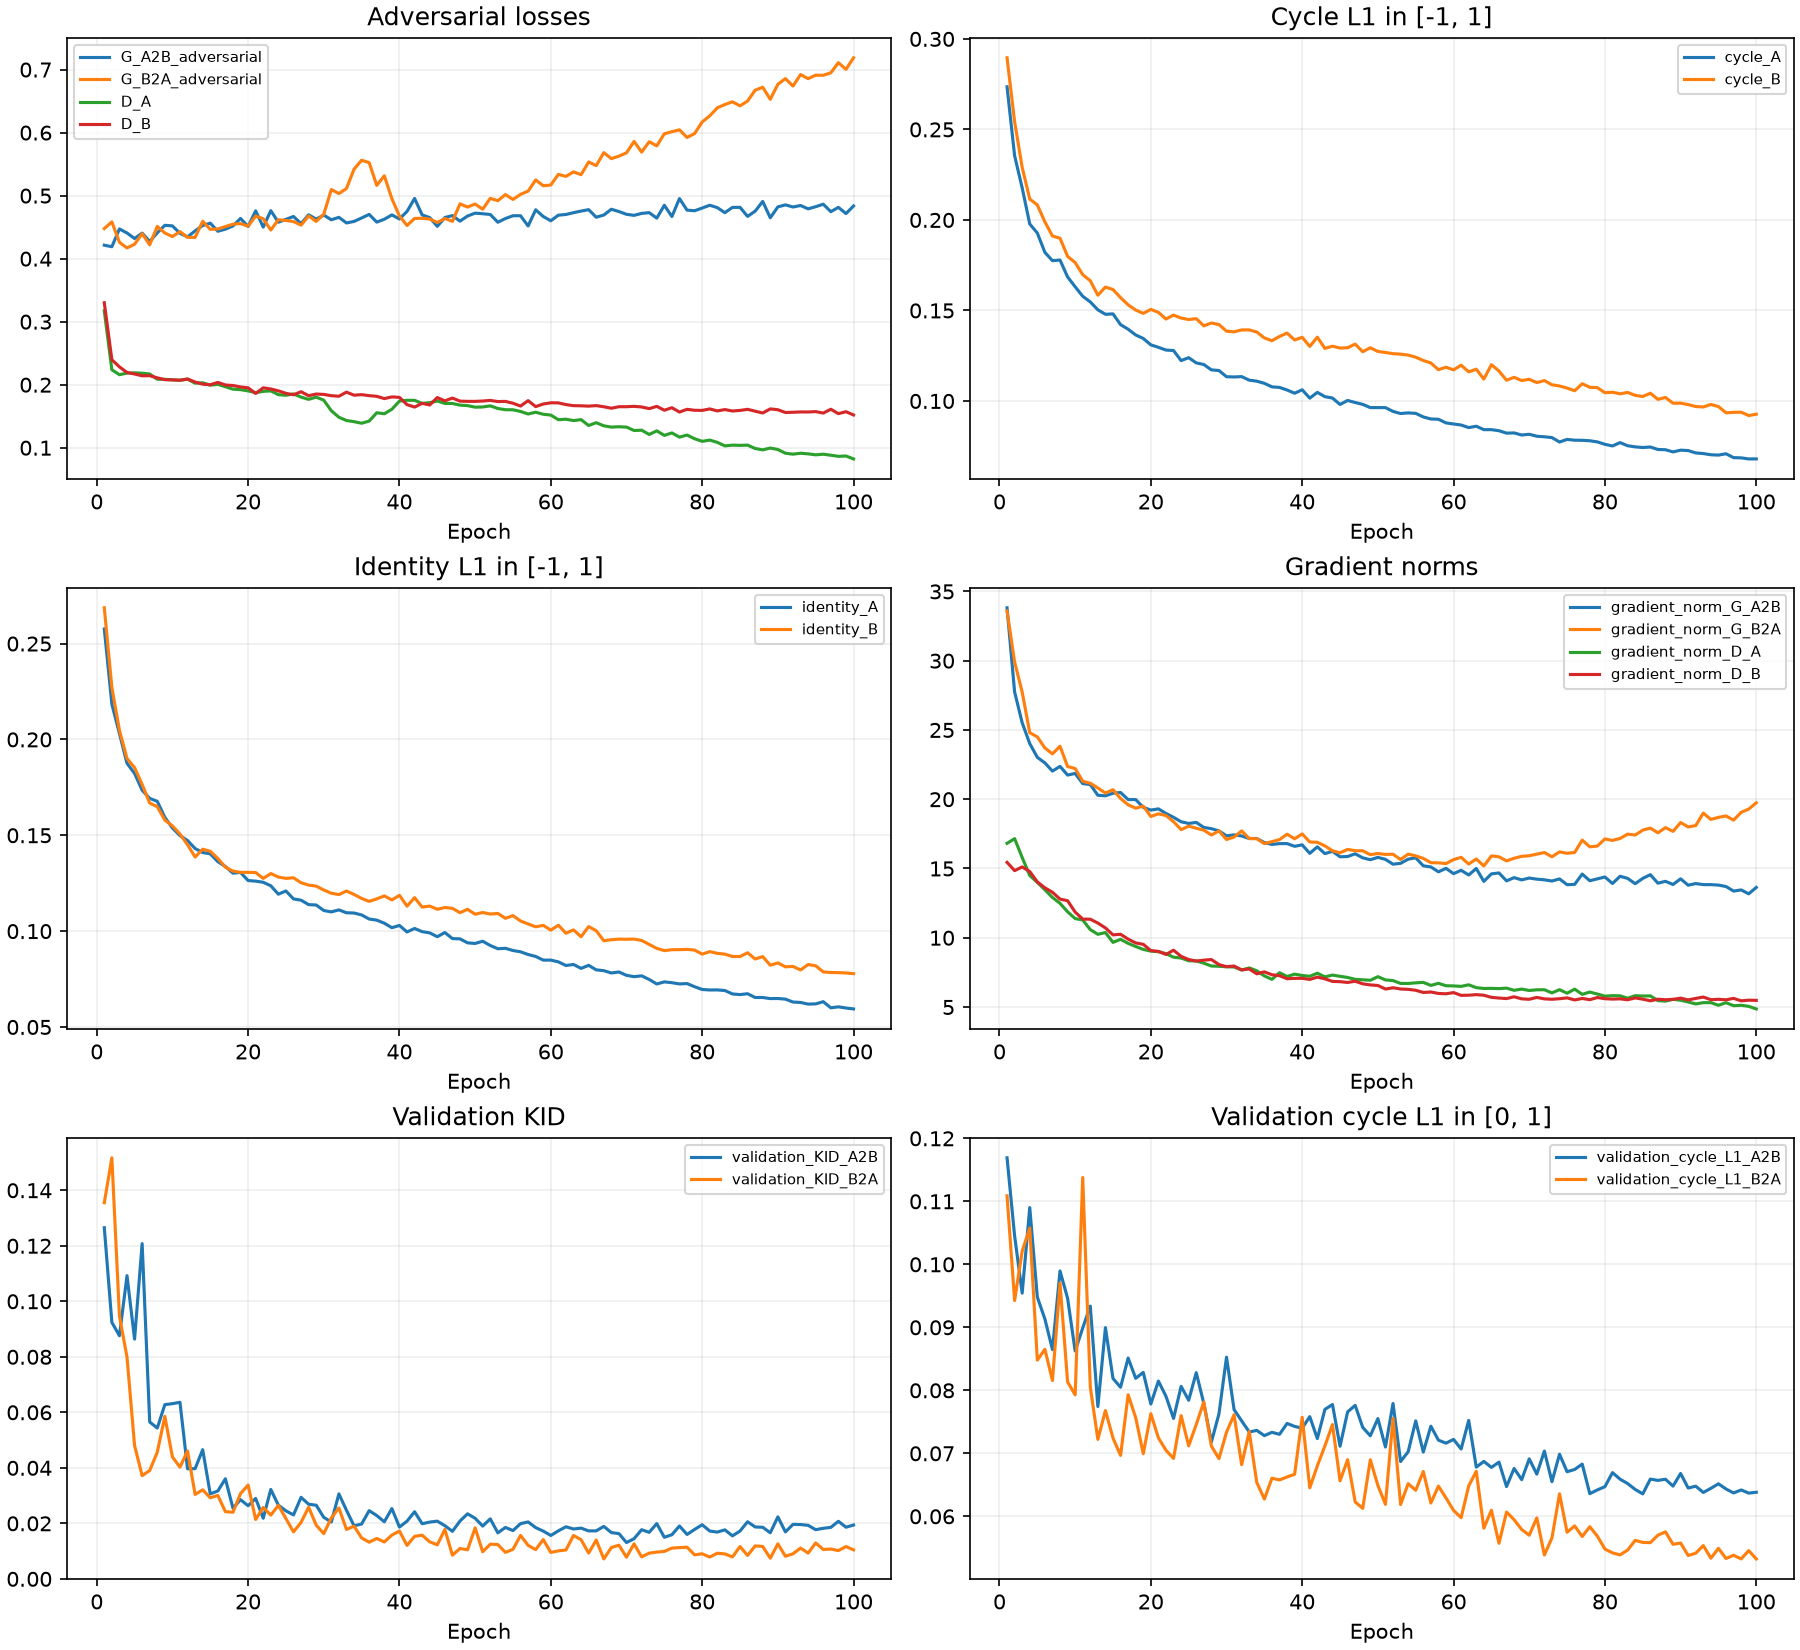

Checkpoint: C:\Users\endle\Downloads\DATA266_Pair41_Lab1\DATA266_Pair41_Lab1-main\task3_gan\Yuyao_Ding\checkpoints\task3_formal_20260927T075834Z_d335ae80\best.pt
Training status: complete | selected epoch: 70


In [9]:
from IPython.display import display
display(Image.open(run_output / "training_curves.png"))
print("Checkpoint:", best_checkpoint)
print("Training status:", run_status["status"], "| selected epoch:", run_status["best_epoch"])